--- Phase 1: Ingesting Data ---
Iterative filtering for manifold stability...
Generating 20 Spherical Clusters...

--- Evaluating Cluster Quality with Silhouette Score ---
The average Silhouette Score is: 0.0328
Interpretation: Poor or ambiguous clustering structure (Common in sparse movie data).

--- Phase 3: Visualizing Cosine Clusters ---


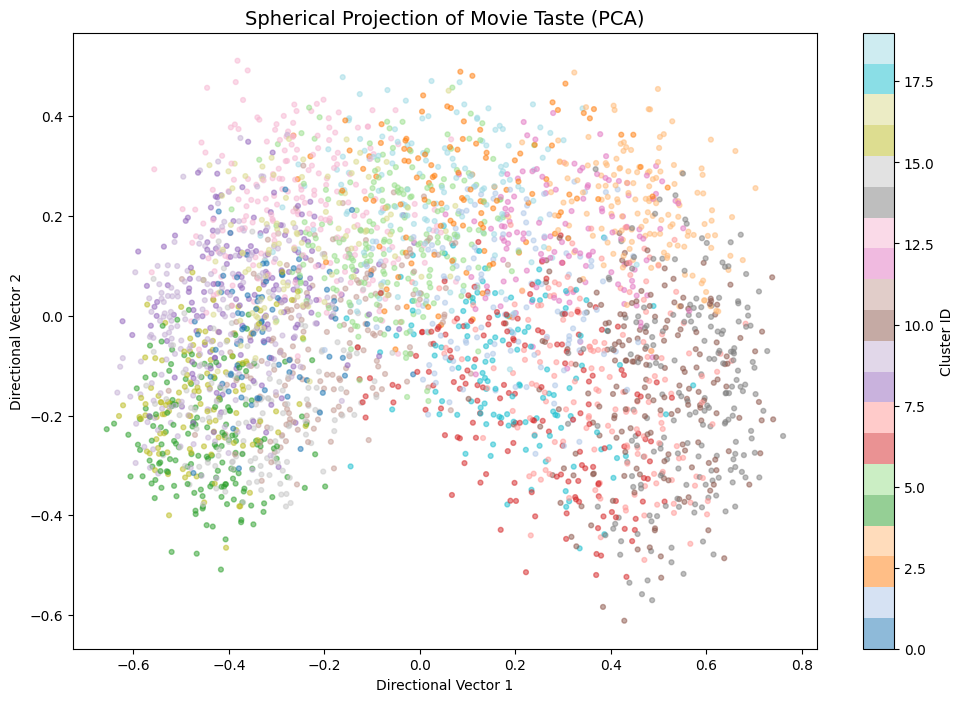

Generating t-SNE plot...


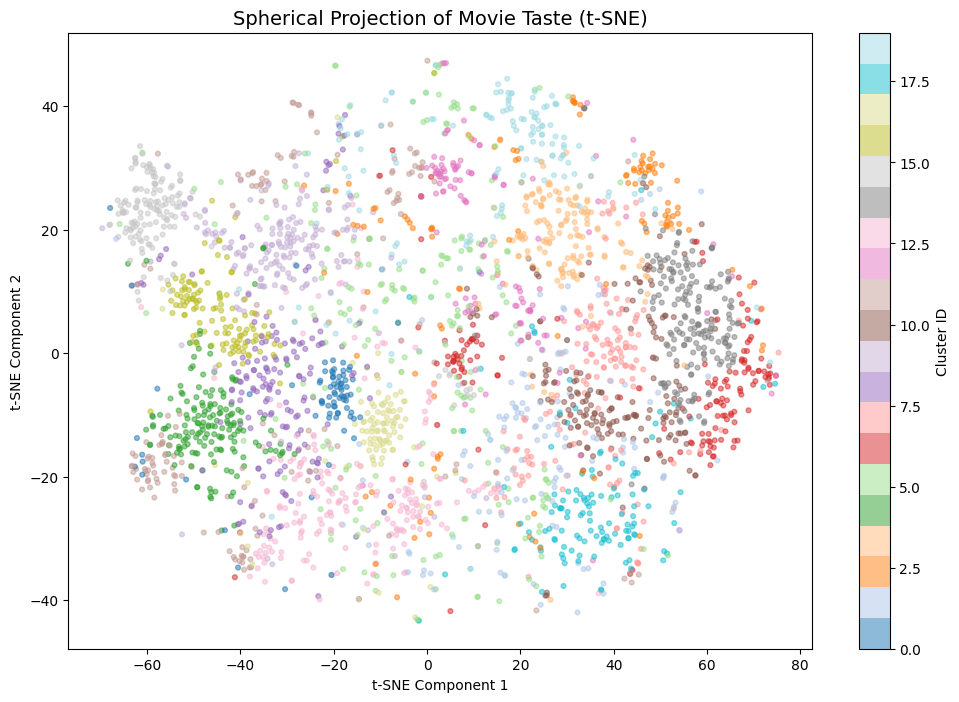

Generating Silhouette Plot...


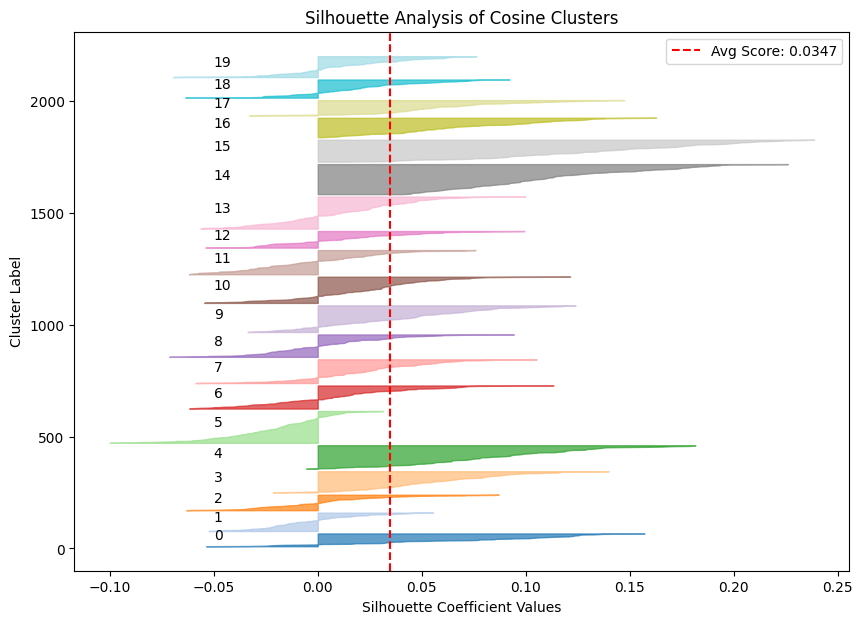

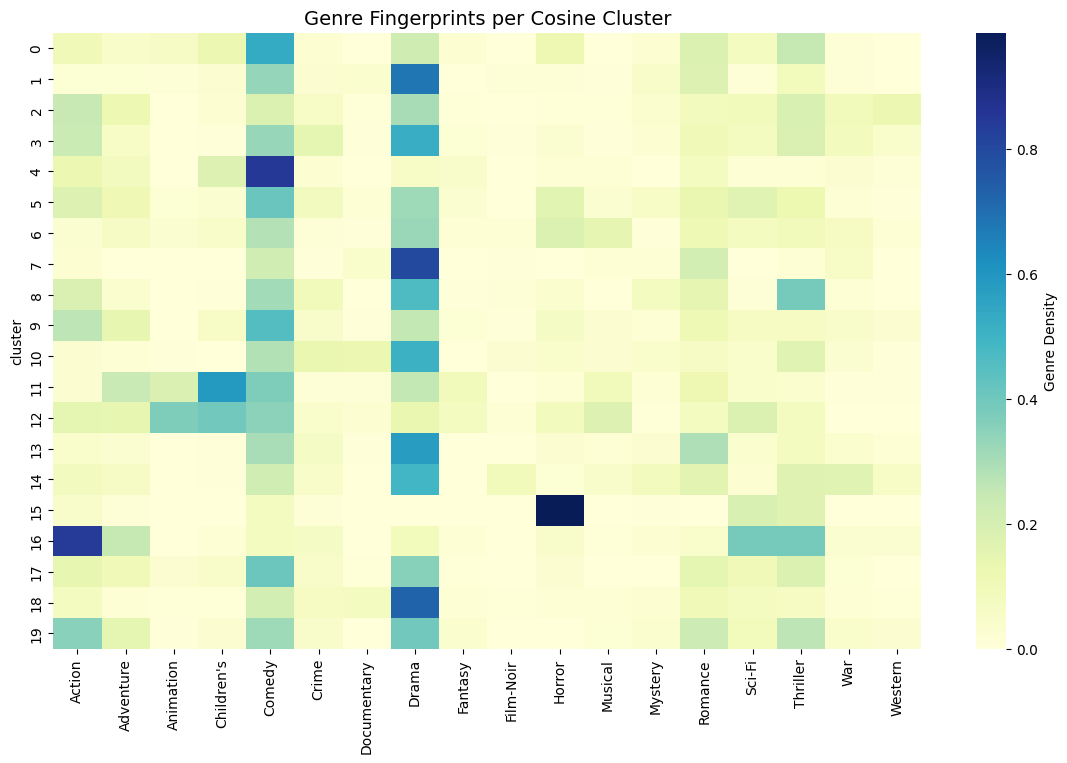


CID  | PERSONA              | AVG COSINE SIM  | SAMPLE MOVIES
-----------------------------------------------------------------------------------------------
0    | Genre Explorers      | 0.5698          | Powder (1995), Underneath, The (1995)
1    | Mystery Specialists  | 0.3448          | Get Shorty (1995), Leaving Las Vegas (1995)
2    | Western Specialists  | 0.3887          | Rob Roy (1995), Black Beauty (1994)
3    | Crime Specialists    | 0.5179          | Heat (1995), Casino (1995)
4    | Comedy Specialists   | 0.6371          | Father of the Bride Part II (1995), Dracula: Dead and Loving It (1995)
5    | Sci-Fi Specialists   | 0.2905          | Othello (1995), French Twist (Gazon maudit) (1995)
6    | Musical Specialists  | 0.4464          | Georgia (1995), Crossing Guard, The (1995)
7    | War Specialists      | 0.4859          | Sense and Sensibility (1995), Persuasion (1995)
8    | Thriller Specialists | 0.5068          | Assassins (1995), Now and Then (1995)
9    | Genre 

In [2]:
import numpy as np
import pandas as pd
import urllib.request
import zipfile
import io
import os
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# System Constants
MODEL_PATH = "netflix_recommender_engine.joblib"
UI_EXPORT_PATH = "clustered_movie_universe.csv"
DIR_NAME = "ml-1m"

# Hyperparameters for Semester 3 Submission
MIN_RATINGS_PER_MOVIE = 20
MIN_RATINGS_PER_USER = 20
VARIANCE_THRESHOLD = 0.60
DEFAULT_K = 20
# =================================================================
# 1. DATA PREPARATION (The Backend)
# =================================================================
def fetch_and_prepare_data():
    url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
    if not os.path.exists(DIR_NAME):
        print("--- Phase 1: Ingesting Data ---")
        r = urllib.request.urlopen(url)
        zipfile.ZipFile(io.BytesIO(r.read())).extractall()

    ratings = pd.read_csv(f"{DIR_NAME}/ratings.dat", sep="::", engine="python",
                         names=['userId', 'movieId', 'rating', 'timestamp'], encoding='latin-1')
    movies = pd.read_csv(f"{DIR_NAME}/movies.dat", sep="::", engine="python",
                        names=['movieId', 'title', 'genres'], encoding='latin-1')

    print("Iterative filtering for manifold stability...")
    while True:
        prev = len(ratings)
        m_ok = ratings.groupby('movieId')['rating'].count() >= MIN_RATINGS_PER_MOVIE
        ratings = ratings[ratings['movieId'].isin(m_ok[m_ok].index)]
        u_ok = ratings.groupby('userId')['rating'].count() >= MIN_RATINGS_PER_USER
        ratings = ratings[ratings['userId'].isin(u_ok[u_ok].index)]
        if len(ratings) == prev: break

    # Mean-centering removes "scale bias" (harsh vs easy critics)
    # This is the first step toward pure Cosine Similarity
    ratings['rating_centered'] = ratings['rating'] - ratings.groupby('userId')['rating'].transform('mean')

    movie_user_matrix = ratings.pivot(index='movieId', columns='userId', values='rating_centered').fillna(0)

    # Latent Factor extraction
    probe = TruncatedSVD(n_components=100, random_state=42)
    probe.fit(movie_user_matrix)
    n_comp = int(np.searchsorted(np.cumsum(probe.explained_variance_ratio_), VARIANCE_THRESHOLD) + 1)

    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    latent_vectors = svd.fit_transform(movie_user_matrix)

    # CRITICAL COSINE STEP: Project all vectors onto the Unit Hypersphere (L2 Normalization)
    # This ensures Euclidean Distance = Cosine Similarity during clustering.
    latent_norm = normalize(latent_vectors, norm='l2', axis=1)

    movie_ids = movie_user_matrix.index.values
    movie_info = movies.set_index('movieId').reindex(movie_ids).fillna('Unknown')

    metadata = {
        'popularity': ratings.groupby('movieId')['rating'].count().reindex(movie_ids).fillna(1).values,
        'titles': movie_info['title'],
        'genres': movie_info['genres'].str.get_dummies(sep='|'),
        'movie_ids': movie_ids
    }
    return latent_norm, metadata
    # =================================================================
# 2. VISUALIZATION SUITE
# =================================================================
def generate_visualizations(latent_norm, labels, personas, metadata):
    print("\n--- Phase 3: Visualizing Cosine Clusters ---")

    # 1. PCA Projection for 2D visualization
    pca = PCA(n_components=2)
    reduced_pca = pca.fit_transform(latent_norm)

    plt.figure(figsize=(12, 8))
    scatter_pca = plt.scatter(reduced_pca[:, 0], reduced_pca[:, 1], c=labels, cmap='tab20', alpha=0.5, s=12)
    plt.colorbar(scatter_pca, label='Cluster ID')
    plt.title("Spherical Projection of Movie Taste (PCA)", fontsize=14)
    plt.xlabel("Directional Vector 1")
    plt.ylabel("Directional Vector 2")
    plt.show()

    # 2. t-SNE Projection for 2D visualization
    print("Generating t-SNE plot...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
    reduced_tsne = tsne.fit_transform(latent_norm)

    plt.figure(figsize=(12, 8))
    scatter_tsne = plt.scatter(reduced_tsne[:, 0], reduced_tsne[:, 1], c=labels, cmap='tab20', alpha=0.5, s=12)
    plt.colorbar(scatter_tsne, label='Cluster ID')
    plt.title("Spherical Projection of Movie Taste (t-SNE)", fontsize=14)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

    # 3. Silhouette Analysis Plot
    print("Generating Silhouette Plot...")
    # Sample for speed if dataset is too large
    sample_size = min(2000, len(latent_norm))
    indices = np.random.choice(len(latent_norm), sample_size, replace=False)
    X_sample = latent_norm[indices]
    y_sample = labels[indices]

    silhouette_avg = silhouette_score(X_sample, y_sample)
    sample_silhouette_values = silhouette_samples(X_sample, y_sample)

    plt.figure(figsize=(10, 7))
    y_lower = 10
    for i in range(len(personas)):
        ith_cluster_silhouette_values = sample_silhouette_values[y_sample == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(float(i) / len(personas))
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Avg Score: {silhouette_avg:.4f}")
    plt.title("Silhouette Analysis of Cosine Clusters")
    plt.xlabel("Silhouette Coefficient Values")
    plt.ylabel("Cluster Label")
    plt.legend()
    plt.show()

    # 4. Genre Heatmap
    genre_df = metadata['genres'].copy()
    genre_df['cluster'] = labels
    cluster_profile = genre_df.groupby('cluster').mean()

    plt.figure(figsize=(14, 8))
    sns.heatmap(cluster_profile, cmap="YlGnBu", cbar_kws={'label': 'Genre Density'})
    plt.title("Genre Fingerprints per Cosine Cluster", fontsize=14)
    plt.show()
    # =================================================================
# 3. THE SPHERICAL CLUSTERING SYSTEM
# =================================================================
class MovieClusteringSystem:
    def __init__(self, k=DEFAULT_K):
        self.k = k
        self.state = None

    def build_clusters(self, latent_norm, metadata):
        print(f"Generating {self.k} Spherical Clusters...")

        # MiniBatchKMeans on L2-normalized data approximates Spherical K-Means
        km = MiniBatchKMeans(n_clusters=self.k, random_state=42, n_init=10).fit(latent_norm)

        # Calculate Cosine Centroids: Mean of members projected back to unit sphere
        centroids = np.zeros((self.k, latent_norm.shape[1]))
        for i in range(self.k):
            mask = km.labels_ == i
            if mask.sum() > 0:
                centroids[i] = normalize(latent_norm[mask].mean(axis=0, keepdims=True))

        # Persona Assignment
        df = metadata['genres'].copy()
        df['cluster'] = km.labels_
        lift = df.groupby('cluster').mean() / df.drop(columns='cluster').mean().replace(0, 1e-6)

        personas = {}
        used = set()
        for cid in lift.max(axis=1).sort_values(ascending=False).index:
            for g in lift.loc[cid].sort_values(ascending=False).index:
                if g not in used and lift.loc[cid, g] > 1.2:
                    personas[cid] = f"{g} Specialists"
                    used.add(g)
                    break
            if cid not in personas: personas[cid] = "Genre Explorers"

        self.state = {
            'latent': latent_norm,
            'labels': km.labels_,
            'centroids': centroids,
            'meta': metadata,
            'personas': personas
        }
        joblib.dump(self.state, MODEL_PATH)

    def evaluate_quality(self):
        """Calculates and interprets the Silhouette Score."""
        print("\n--- Evaluating Cluster Quality with Silhouette Score ---")
        # Sample to avoid memory/time bottlenecks during evaluation
        sample_size = min(2500, len(self.state['latent']))
        indices = np.random.choice(len(self.state['latent']), sample_size, replace=False)

        score = silhouette_score(self.state['latent'][indices], self.state['labels'][indices])
        print(f"The average Silhouette Score is: {score:.4f}")

        if score > 0.5:
            print("Interpretation: Strong structure found.")
        elif score > 0.2:
            print("Interpretation: Reasonable structure found.")
        else:
            print("Interpretation: Poor or ambiguous clustering structure (Common in sparse movie data).")
        return score

    def print_cosine_summary(self):
        """Prints a summary validating the Cosine alignment of the clusters."""
        print("\n" + "="*95)
        print(f"{'CID':<4} | {'PERSONA':<20} | {'AVG COSINE SIM':<15} | {'SAMPLE MOVIES'}")
        print("-" * 95)

        for i in range(self.k):
            mask = self.state['labels'] == i
            cluster_data = self.state['latent'][mask]

            if len(cluster_data) > 1:
                avg_sim = np.dot(cluster_data, self.state['centroids'][i]).mean()
            else:
                avg_sim = 1.0

            titles = self.state['meta']['titles'][mask].head(2).tolist()
            print(f"{i:<4} | {self.state['personas'][i]:<20} | {avg_sim:<15.4f} | {', '.join(titles)}")
        print("="*95)

    def export_for_ui(self):
        if not self.state: return
        ui_data = pd.DataFrame({
            'movie_id': self.state['meta']['movie_ids'],
            'title': self.state['meta']['titles'],
            'cluster_id': self.state['labels'],
            'persona': pd.Series(self.state['labels']).map(self.state['personas']).values
        })
        ui_data.to_csv(UI_EXPORT_PATH, index=False)
        print(f"UI Data Exported: {UI_EXPORT_PATH}")
        # =================================================================
# EXECUTION
# =================================================================
if __name__ == "__main__":
    system = MovieClusteringSystem()

    if os.path.exists(MODEL_PATH):
        print("Loading pre-computed model...")
        system.state = joblib.load(MODEL_PATH)
    else:
        latents, meta = fetch_and_prepare_data()
        system.build_clusters(latents, meta)

    # 1. Quality Evaluation
    system.evaluate_quality()

    # 2. Visualization
    generate_visualizations(
        system.state['latent'],
        system.state['labels'],
        system.state['personas'],
        system.state['meta']
    )

    # 3. Cosine Alignment Summary
    system.print_cosine_summary()

    # 4. UI Export
    system.export_for_ui()